In [1]:
import json
import os
import urllib


def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as f:
            f.write(text_data)

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    return data


file_path = "../data/alpaca-data.json"
url = (
    "https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/main/alpaca_data.json"
)

data = download_and_load_file(file_path, url)
print(f"Number of entries: {len(data)}")


def format_input(entry, prompt_style="alpaca"):
    if prompt_style == "alpaca":
        instruction_text = (
            f"Below is an instruction that describes a task. "
            f"Write a response that appropriately completes the request."
            f"\n\n### Instruction:\n{entry['instruction']}"
        )

        input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

        return instruction_text + input_text
    elif prompt_style == "phi-3":
        punc = entry["instruction"][-1]
        user_request = f"<|user|>\n{entry['instruction'][:-1]}"
        if entry["input"]:
            user_request += f": {entry['input']}"
        else:
            user_request += punc
        return user_request
    else:
        raise ValueError(f"'{prompt_style}' is not a recognized prompt style.")


def full_instruction_prompt_tokenize(entry, tokenizer, prompt_style="alpaca"):
    model_input_tokenized = tokenizer.encode(format_input(entry, prompt_style))
    if prompt_style == "alpaca":
        desired_response = f"\n\n### Response:\n{entry['output']}"
    elif prompt_style == "phi-3":
        desired_response = f"\n\n<|assistant|>\n{entry['output']}"
    else:
        raise ValueError(f"'{prompt_style}' is not a recognized prompt style.")
    return model_input_tokenized, tokenizer.encode(desired_response)


train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion : train_portion + test_portion]
val_data = data[train_portion + test_portion :]

print(f"Training set length: {len(train_data)}")
print(f"Validation set length: {len(val_data)}")
print(f"Test set length: {len(test_data)}")

Number of entries: 52002
Training set length: 44201
Validation set length: 2601
Test set length: 5200


In [2]:
import torch
from torch.utils.data import Dataset


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer, prompt_style="alpaca"):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            self.encoded_texts.append(
                full_instruction_prompt_tokenize(entry, tokenizer, prompt_style)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)


import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")


def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=1024,
    device="cpu",
    mask_instructions=False,
):
    batch_max_length = max(len(item[0] + item[1]) for item in batch) + 1
    inputs_lst, targets_lst = list(), list()

    for item in batch:
        instruction_length = len(item[0])
        new_item = item[0].copy() + item[1].copy()
        new_item += [pad_token_id]
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))

        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        if mask_instructions:
            targets[: instruction_length - 1] = ignore_index

        # Set to the context length of the model
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [3]:
from functools import partial

device = torch.device("cuda")

instruction_masking_collate_fn = partial(
    custom_collate_fn, device=device, allowed_max_length=1024, mask_instructions=True
)

In [4]:
from gpt_download import download_and_load_gpt2
from gpt_modules import GPTModel
from weight_loader import load_weights_into_gpt

2025-12-05 21:43:43.790020: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-05 21:43:43.790095: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-05 21:43:43.791593: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-05 21:43:43.799167: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-05 21:43:44.855158: W tensorflow/compiler/tf2

In [5]:
BASE_CONFIG = {
    "vocab_size": 50_257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True,
}

model_configs = {"gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16}}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


In [6]:
from functools import partial
from torch.utils.data import DataLoader
from gpt_training_utils import (
    generate,
    text_to_token_ids,
    token_ids_to_text,
    calc_loss_loader,
    train_model_with_bells_and_whistles,
)

instruction_masking_collate_fn = partial(
    custom_collate_fn, device=device, allowed_max_length=1024, mask_instructions=True
)

num_workers = 0
batch_size = 4

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers,
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)

In [7]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print(f"Training Loss: {train_loss}")
print(f"Validation Loss: {val_loss}")

Training Loss: 2.402444314956665
Validation Loss: 2.6414263248443604


In [8]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.1)
num_epochs = 2
warmup_steps = int(0.2 * len(train_loader) * num_epochs)

train_losses, val_losses, track_tokens_seen, track_lrs = (
    train_model_with_bells_and_whistles(
        model,
        train_loader,
        val_loader,
        optimizer,
        device,
        num_epochs,
        eval_freq=5,
        eval_iter=1,
        start_context=format_input(val_data[0]),
        tokenizer=tokenizer,
        warmup_steps=warmup_steps,
        initial_lr=1e-5,
        min_lr=1e-5,
    )
)

end_time = time.time()
execution_time_mins = (end_time - start_time) / 60
print(f"Training completed in {execution_time_mins:.2f} minutes.")

Ep 1 (Iter 000000):  Train loss 1.513,  Val loss 2.566
Ep 1 (Iter 000005):  Train loss 2.464,  Val loss 2.456
Ep 1 (Iter 000010):  Train loss 1.814,  Val loss 2.409
Ep 1 (Iter 000015):  Train loss 1.202,  Val loss 2.357
Ep 1 (Iter 000020):  Train loss 1.837,  Val loss 2.330
Ep 1 (Iter 000025):  Train loss 1.747,  Val loss 2.315
Ep 1 (Iter 000030):  Train loss 1.888,  Val loss 2.308
Ep 1 (Iter 000035):  Train loss 2.153,  Val loss 2.303
Ep 1 (Iter 000040):  Train loss 1.627,  Val loss 2.301
Ep 1 (Iter 000045):  Train loss 1.582,  Val loss 2.290
Ep 1 (Iter 000050):  Train loss 1.261,  Val loss 2.280
Ep 1 (Iter 000055):  Train loss 1.821,  Val loss 2.269
Ep 1 (Iter 000060):  Train loss 1.415,  Val loss 2.261
Ep 1 (Iter 000065):  Train loss 1.639,  Val loss 2.254
Ep 1 (Iter 000070):  Train loss 1.935,  Val loss 2.252
Ep 1 (Iter 000075):  Train loss 2.240,  Val loss 2.249
Ep 1 (Iter 000080):  Train loss 2.388,  Val loss 2.245
Ep 1 (Iter 000085):  Train loss 1.772,  Val loss 2.242
Ep 1 (Iter

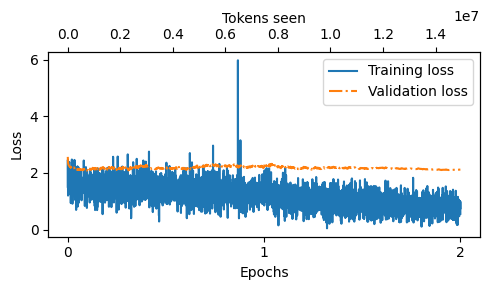

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, track_tokens_seen, train_losses, val_losses)

In [11]:
import re

file_name = f"../models/{re.sub(r'[ ()]', '', CHOOSE_MODEL)}-sft-alpaca.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as ../models/gpt2-medium355M-sft-alpaca.pth


In [14]:
# Save results for the test set from Raschka
file_path_raschka = "../data/instruction-data.json"
url_raschka = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json"

data = download_and_load_file(file_path_raschka, url_raschka)

train_portion_raschka = int(len(data) * 0.85)
test_portion_raschka = int(len(data) * 0.1)
test_data_raschka = data[
    train_portion_raschka : train_portion_raschka + test_portion_raschka
]

test_dataset_raschka = InstructionDataset(test_data_raschka, tokenizer)
test_loader = DataLoader(
    test_dataset_raschka,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)

from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data_raschka), total=len(test_data_raschka)):
    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256,
    )

    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text) :].replace("### Response:", "").strip()
    )
    test_data_raschka[i]["model_response"] = response_text

with open("instruction-data-with-response-alpaca-dataset-finetune.json", "w") as f:
    json.dump(test_data_raschka, f, indent=4)

100%|██████████| 110/110 [00:50<00:00,  2.18it/s]


### LoRA

In [15]:
import math
import torch
from torch.nn import Module


class LoRALayer(Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super(LoRALayer, self).__init__()
        self.A = torch.nn.Parameter(torch.empty(in_dim, rank))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        self.B = torch.nn.Parameter(
            torch.zeros(rank, out_dim)
        )  # Initialize as zero, so LoRA starts as AB=0
        self.alpha = alpha  # Scaling factor

    def forward(self, x):
        x = self.alpha * (x @ self.A @ self.B)
        return x


class LinearWithLoRA(Module):
    def __init__(self, linear, rank, alpha):
        super(LinearWithLoRA, self).__init__()
        self.linear = linear
        self.lora = LoRALayer(
            in_dim=linear.in_features,
            out_dim=linear.out_features,
            rank=rank,
            alpha=alpha,
        )

    def forward(self, x):
        linear_out = self.linear(x)  # x @ W (Original weights)
        lora_out = self.lora(x)  # x @ AB
        return linear_out + lora_out  # x @ W + x @ AB = x @ (W + AB)


def replace_linear_with_lora_(
    model, rank, alpha, verbose=False
):  # Added "_" to the end, because works in-place
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            setattr(model, name, LinearWithLoRA(module, rank, alpha))
            if verbose:
                print(f"{name} has been changed to LinearWithLoRA")
        else:
            replace_linear_with_lora_(module, rank, alpha)

In [16]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
for param in model.parameters():
    param.requires_grad = False

replace_linear_with_lora_(model, rank=16, alpha=16)

model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print(f"Training Loss: {train_loss}")
print(f"Validation Loss: {val_loss}")

Training Loss: 2.402444314956665
Validation Loss: 2.6414263248443604


In [17]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.1)
num_epochs = 2
warmup_steps = int(0.2 * len(train_loader) * num_epochs)

train_losses, val_losses, track_tokens_seen, track_lrs = (
    train_model_with_bells_and_whistles(
        model,
        train_loader,
        val_loader,
        optimizer,
        device,
        num_epochs,
        eval_freq=5,
        eval_iter=1,
        start_context=format_input(val_data[0]),
        tokenizer=tokenizer,
        warmup_steps=warmup_steps,
        initial_lr=1e-5,
        min_lr=1e-5,
    )
)

end_time = time.time()
execution_time_mins = (end_time - start_time) / 60
print(f"Training completed in {execution_time_mins:.2f} minutes.")

Ep 1 (Iter 000000):  Train loss 1.486,  Val loss 2.551
Ep 1 (Iter 000005):  Train loss 2.463,  Val loss 2.467
Ep 1 (Iter 000010):  Train loss 1.818,  Val loss 2.473
Ep 1 (Iter 000015):  Train loss 1.183,  Val loss 2.438
Ep 1 (Iter 000020):  Train loss 1.831,  Val loss 2.425
Ep 1 (Iter 000025):  Train loss 1.716,  Val loss 2.429
Ep 1 (Iter 000030):  Train loss 1.974,  Val loss 2.433
Ep 1 (Iter 000035):  Train loss 2.207,  Val loss 2.425
Ep 1 (Iter 000040):  Train loss 1.642,  Val loss 2.421
Ep 1 (Iter 000045):  Train loss 1.642,  Val loss 2.411
Ep 1 (Iter 000050):  Train loss 1.311,  Val loss 2.382
Ep 1 (Iter 000055):  Train loss 1.874,  Val loss 2.345
Ep 1 (Iter 000060):  Train loss 1.427,  Val loss 2.324
Ep 1 (Iter 000065):  Train loss 1.679,  Val loss 2.309
Ep 1 (Iter 000070):  Train loss 1.971,  Val loss 2.297
Ep 1 (Iter 000075):  Train loss 2.287,  Val loss 2.285
Ep 1 (Iter 000080):  Train loss 2.402,  Val loss 2.276
Ep 1 (Iter 000085):  Train loss 1.772,  Val loss 2.271
Ep 1 (Iter

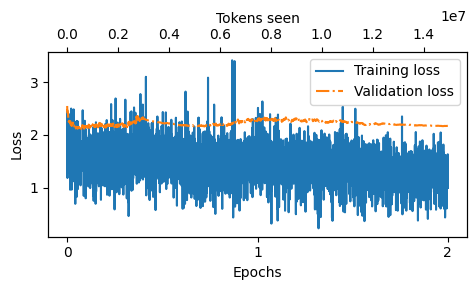

In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, track_tokens_seen, train_losses, val_losses)

In [19]:
import re

file_name = f"../models/{re.sub(r'[ ()]', '', CHOOSE_MODEL)}-sft-alpaca-lora.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as ../models/gpt2-medium355M-sft-alpaca-lora.pth


In [20]:
# Save results for the test set from Raschka
file_path_raschka = "../data/instruction-data.json"
url_raschka = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json"

data = download_and_load_file(file_path_raschka, url_raschka)

train_portion_raschka = int(len(data) * 0.85)
test_portion_raschka = int(len(data) * 0.1)
test_data_raschka = data[
    train_portion_raschka : train_portion_raschka + test_portion_raschka
]

test_dataset_raschka = InstructionDataset(test_data_raschka, tokenizer)
test_loader = DataLoader(
    test_dataset_raschka,
    batch_size=batch_size,
    collate_fn=instruction_masking_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)

from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data_raschka), total=len(test_data_raschka)):
    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256,
    )

    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text) :].replace("### Response:", "").strip()
    )
    test_data_raschka[i]["model_response"] = response_text

with open("instruction-data-with-response-alpaca-dataset-finetune-lora.json", "w") as f:
    json.dump(test_data_raschka, f, indent=4)

100%|██████████| 110/110 [01:30<00:00,  1.22it/s]
